## ISSW_Analyze

Definition of the absorption optical depth:
$$
\tau = log({I_0 \over I})
$$

Definition of the absorption Angstrom exponent:
$$
AAE = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import ISSWlib as IS
import pandas as pd
import os
%matplotlib inline

In [2]:
!pwd

/home/chemistry/LAI_in_snow/ISSW


In [3]:
# Choose the spectrum folder and load in the list of spectra there
# spectrum_folder = 'Rainier_and_MtCook_comparison/'
# spectrum_folder = 'UPS_Rainier2025-07-03-01/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Adams_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Misc_1/'; filtertype = 'millipore'
# spectrum_folder = 'Ulyana ful/'; filtertype = 'millipore'
spectrum_folder = 'Ponderosa pine pollen/'; filtertype = 'millipore'
# spectrum_folder = 'Rainier dirt/'; filtertype = 'millipore'

# spectrum_folder = 'UPS_2016Chile/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'
# spectrum_folder = 'UPS_INKStandards/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucInc/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucFul/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'

# !ls -l '2026July7'
# !ls -l '2026July7/NucFul'
# !ls -l '2026July7/NucInc'

# Checking location of files
files = os.listdir(spectrum_folder)
print(files)

['PP2026-2.txt', 'Blank2.txt', 'PP2026-1.txt', 'Blank.txt', 'PP2026-3.txt', 'spectrum_files.txt']


In [4]:
# Parameter file
# parameter_filename = 'calibration parameters from UPS_INKStandards (July 13, 2026).csv'
# parameter_filename = 'calibration parameters from 2026July7 NucFul (July 13, 2026).csv'
# parameter_filename = 'calibration III parameters from Ulyana ful (July 21, 2026).csv'
# parameter_filename = 'calibration III parameters from Ink (July 21, 2026).csv'
# parameter_filename = 'calibration parameters from Ulyana ful (July 16, 2026), with iterative adj of AAE.csv'
# parameter_filename = 'calibration III parameters from Ulyana ful (July 21, 2026).csv'
parameter_filename = 'calibration IV parameters (nucleopore) (July 22, 2026).csv'

df = pd.read_csv(parameter_filename)
print(df)
calibration_spectrum_folder = df.at[0, 'calibration_spectrum_folder']
betabar_450_std = df.at[0,'betabar_450_std']
betabar_600_std = df.at[0,'betabar_600_std']
filtertype_std = df.at[0,'filtertype_std']
p_L_450 = df.at[0,'p_L_450'],
p_L_600 = df.at[0,'p_L_600'],
AAE_std = df.at[0,'AAE_std']

p_L_450 = p_L_450[0]; print(p_L_450)
p_L_600 = p_L_600[0]; print(p_L_600)
p_L_450 = np.fromstring(p_L_450[1:-1], dtype=float, sep=' '); print(p_L_450)
p_L_600 = np.fromstring(p_L_600[1:-1], dtype=float, sep=' '); print(p_L_600)

  calibration_spectrum_folder  betabar_450_std  betabar_600_std  \
0           UPS_INKStandards/         0.062232         0.054982   

  filtertype_std                                            p_L_450  \
0     nucleopore  [ 6.25586230e+00  6.23233270e+00 -2.04196145e-05]   

                                             p_L_600   AAE_std  
0  [ 5.40369813e+00  7.86488659e+00 -6.66150850e-06]  0.430525  
[ 6.25586230e+00  6.23233270e+00 -2.04196145e-05]
[ 5.40369813e+00  7.86488659e+00 -6.66150850e-06]
[ 6.25586230e+00  6.23233270e+00 -2.04196145e-05]
[ 5.40369813e+00  7.86488659e+00 -6.66150850e-06]


In [5]:
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  Ponderosa pine pollen/spectrum_files.txt , finding these spectra:
      PP2026-1.txt
      PP2026-2.txt
      PP2026-3.txt


In [6]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
I_1 = I_450
I_2 = I_600

lambda_450 =  450.0
lambda_600 =  600.0


In [7]:
# Preallocate arrays and other constants
chi_observed = np.zeros((number_of_loadings,2))
bot = np.log(lambda_nm[I_1]/lambda_nm[I_2])

chi1, chi2 =  0.414783205221644 0.15795090980541973
chi1, chi2 =  0.2467277321387005 0.09731505089941017
chi1, chi2 =  1.080559664197836 0.4494626394448333


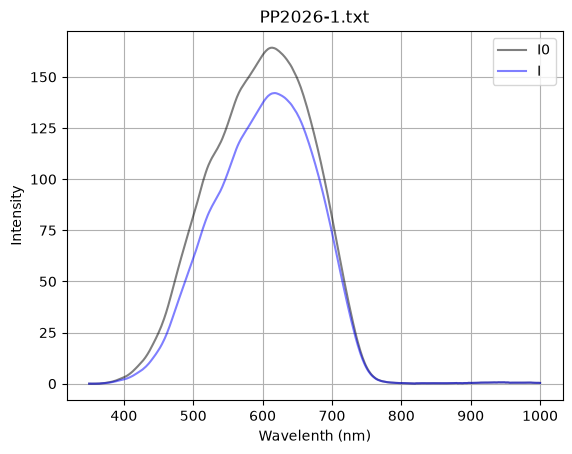

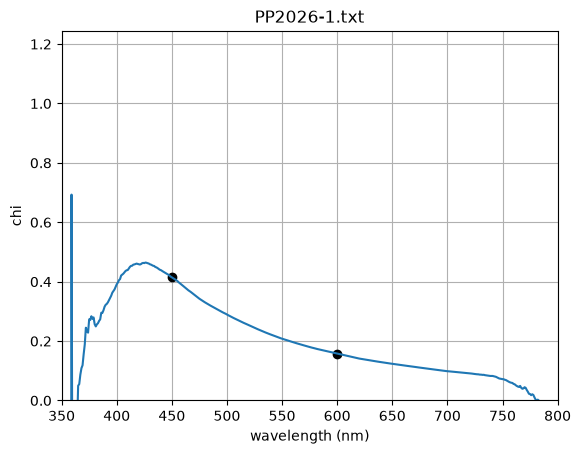

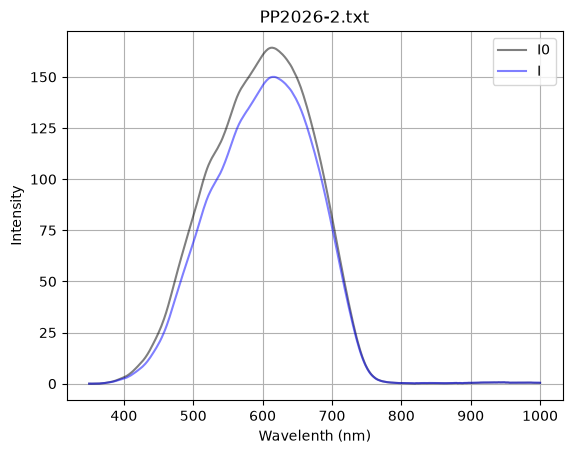

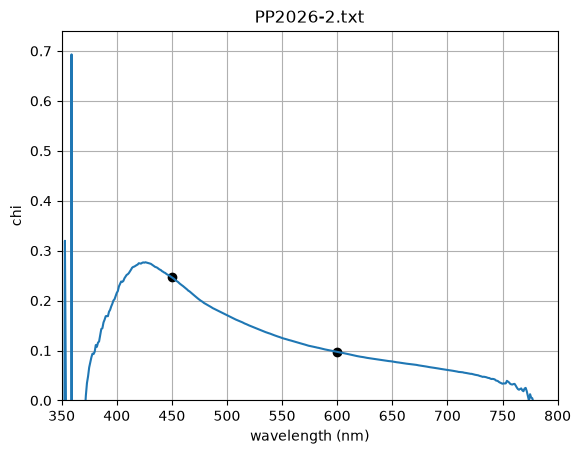

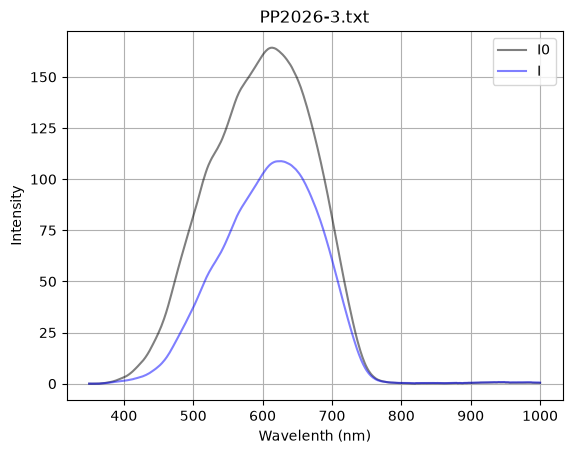

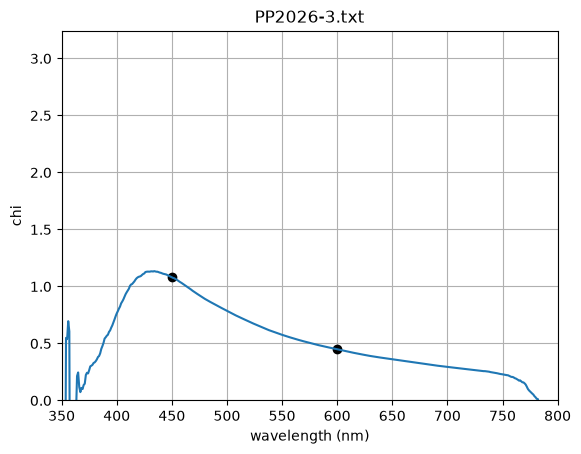

In [8]:
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get the observed chi-values
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    print('chi1, chi2 = ', chi[I_1],chi[I_2])
    
    # Save chi values at lambda1 and lambda2
    chi_450_obs = chi[I_1]
    chi_600_obs = chi[I_2]

    # Reduced optical depths
    taubar_450_obs = betabar_450_std*np.polyval(p_L_450,chi_450_obs)
    taubar_600_obs = betabar_600_std*np.polyval(p_L_600,chi_600_obs)

    # Get the Angstrom exponent
    top = np.log(taubar_450_obs/taubar_600_obs)
    AAE = -top/bot
    
    # Record for plotting later
    if i==0:
        AAE_obs_list = AAE
        taubar_450_obs_list = taubar_450_obs
        taubar_600_obs_list = taubar_600_obs
    else:
        AAE_obs_list = np.append(AAE_obs_list,AAE)
        taubar_450_obs_list = np.append(taubar_450_obs_list,taubar_450_obs)
        taubar_600_obs_list = np.append(taubar_600_obs_list,taubar_600_obs)

In [9]:
taubar_450_obs_list

array([0.22785207, 0.11939145, 0.87366097])

In [10]:
# Getting equivalent loadings
L_450_equiv = taubar_450_obs_list/betabar_450_std
L_600_equiv = taubar_600_obs_list/betabar_600_std

print(filtertype_std)
if filtertype_std == 'nucleopore' and filtertype == 'millipore':
    print('applying a nucleopore-to-millipore correction')
    filter_factor = 3
    L_450_equiv /= filter_factor
    L_600_equiv /= filter_factor
elif filtertype_std == 'millipore' and filtertype == 'nucleopore':
    print('applying a millipore-to- nucleopore correction')
    filter_factor = 2.55
    L_450_equiv *= filter_factor
    L_600_equiv *= filter_factor
    
# Report out
for j in range(number_of_loadings):
    print('std-equivalent loading @450, 600, AAE = ', spectrum_list[j], L_450_equiv[j], L_600_equiv[j], AAE_obs_list[j])


nucleopore
applying a nucleopore-to-millipore correction
std-equivalent loading @450, 600, AAE =  PP2026-1.txt 1.2204456715230048 0.45902447972085775 3.829651632716754
std-equivalent loading @450, 600, AAE =  PP2026-2.txt 0.6394972815646011 0.2721797942424371 3.399842714953857
std-equivalent loading @450, 600, AAE =  PP2026-3.txt 4.67959640317658 1.5422010316800099 4.288955178749229
